In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Social Network Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [3]:
df.drop('User ID',axis=1,inplace=True)

In [4]:
df['Gender'] = df['Gender'].map({'Male':1 ,'Female':0})
df

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0
...,...,...,...,...
395,0,46,41000,1
396,1,51,23000,1
397,0,50,20000,1
398,1,36,33000,0


## Train Test Split

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)


In [11]:
X_train.shape, X_test.shape


((280, 3), (120, 3))

In [12]:
X_train

,Gender,Age,EstimatedSalary
92,1,26,15000
223,1,60,102000
234,0,38,112000
232,1,40,107000
377,0,42,53000
...,...,...,...
323,0,48,30000
192,1,29,43000
117,1,36,52000
47,0,27,54000


In [13]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()

In [17]:
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.fit_transform(X_test)

x_train_scaled

array([[ 0.99288247, -1.1631724 , -1.5849703 ],
       [ 0.99288247,  2.17018137,  0.93098672],
       [-1.00716855,  0.0133054 ,  1.22017719],
       [ 0.99288247,  0.20938504,  1.07558195],
       [-1.00716855,  0.40546467, -0.48604654],
       [ 0.99288247, -0.28081405, -0.31253226],
       [ 0.99288247,  0.99370357, -0.8330751 ],
       [-1.00716855,  0.99370357,  1.8563962 ],
       [-1.00716855,  0.0133054 ,  1.24909623],
       [ 0.99288247, -0.86905295,  2.26126285],
       [-1.00716855, -1.1631724 , -1.5849703 ],
       [ 0.99288247,  2.17018137, -0.80415605],
       [ 0.99288247, -1.35925203, -1.46929411],
       [ 0.99288247,  0.40546467,  2.2901819 ],
       [-1.00716855,  0.79762394,  0.75747245],
       [ 0.99288247, -0.96709276, -0.31253226],
       [ 0.99288247,  0.11134522,  0.75747245],
       [ 0.99288247, -0.96709276,  0.55503912],
       [ 0.99288247,  0.30742485,  0.06341534],
       [ 0.99288247,  0.69958412, -1.26686079],
       [-1.00716855, -0.47689368, -0.023

In [20]:
x_train_scaled =pd.DataFrame(data = x_train_scaled, columns = X_train.columns)
x_test_scaled = pd.DataFrame(data = x_test_scaled, columns = X_train.columns)

In [21]:
np.round(X_train.describe(),2)

,Gender,Age,EstimatedSalary
count,280.0,280.00,280.00
mean,0.5,37.86,69807.14
std,0.5,10.22,34641.20
min,0.0,18.00,15000.00
25%,0.0,30.00,43000.00
50%,1.0,37.00,70500.00
75%,1.0,46.00,88000.00
max,1.0,60.00,150000.00


In [22]:
np.round(x_train_scaled.describe(),2)

,Gender,Age,EstimatedSalary
count,280.00,280.00,280.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.01,-1.95,-1.58
25%,-1.01,-0.77,-0.78
50%,0.99,-0.08,0.02
75%,0.99,0.80,0.53
max,0.99,2.17,2.32


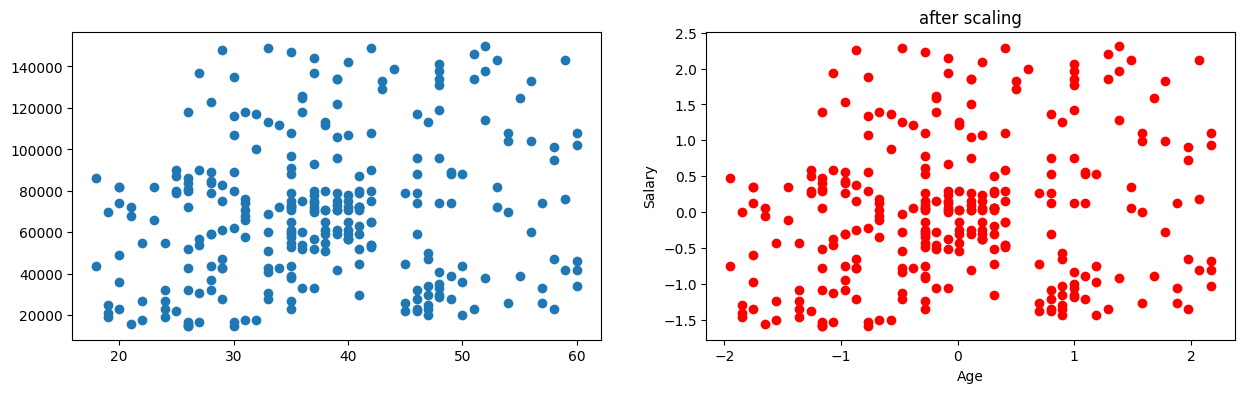

In [25]:
fig,(x1,x2) = plt.subplots(1,2,figsize=(15,4))
x1.scatter(X_train['Age'],X_train['EstimatedSalary'])
plt.title("before")
plt.xlabel("Age")
plt.ylabel('Salary')
x2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color='red')
plt.title('after scaling')
plt.xlabel("Age")
plt.ylabel('Salary')
plt.show()